# Training (YOLO Model)

This notebook contains the code used to perform the main training loop for the YOLO26 based human pose estimation model. The actual training code in implemented in `detect.py`.

In [1]:
import sys

import matplotlib.pyplot as plt

In [2]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import detect
import dataset

In [3]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(detect)
importlib.reload(dataset);

In [ ]:
model = detect.CustomHeadedYolo(path="../nets")
# Train for a maximum of 50 epochs on the complete dataset.
detect.train_epochs_in(50, "../nets/yolo", "../stats/yolo", model)

In [ ]:
# Load one example sample from the dataset.
data = dataset.YoloDataset("../data/yolo/val")
img, ann = data[5]
# Try to run the learned detector on the sample.
detector = detect.CustomPoseDetector(model)
mean, cov = detector.detect_simple(img.unsqueeze(0).to("cuda"))[0]
# Try also to use the baseline YOLO model.
detector2 = detect.PoseDetector(path="../nets", compile=False)
mean2, cov2 = detector2.detect_simple(img.unsqueeze(0))[0]

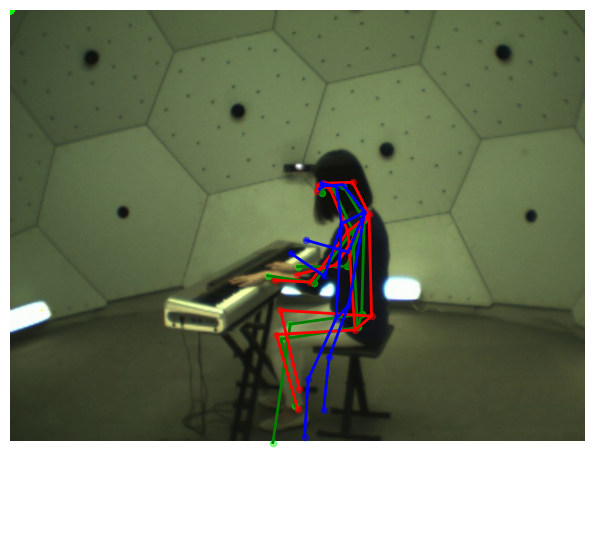

In [ ]:
# Visualize the results.
plt.figure(figsize=(8, 7))
for kp in ann:
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='green', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#00ff0070')
for kp in mean2.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='red', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#ff000070')
for kp in mean.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='blue', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#0000ff70')
plt.imshow(img.permute(1, 2, 0))
plt.ylim(600, 0)
plt.axis("off")
plt.show()